<h2> UNE discrétisation du DSM : le modèle DDPM</h2>

DDPM équivaut à une SDE à variance conservée (VP SDE) avec un bruitage contrôlé

Dans ce script, on essaie reproduire le DDPM comme dans l'article original de Ho. 

Imports

In [2]:
import torch
import torchvision
from matplotlib import pyplot as plt
from sympy.abc import sigma
from tqdm.notebook import tqdm
from torch import nn, optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np

Chargement des données

In [3]:
TRANSFORMS = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # en gris, non necessaire
    transforms.ToTensor(), # transformation en tenseur
]) # sorte de fonction qui permet de transformer plusieur fois l'image

ds = torchvision.datasets.MNIST("/tmp/mnist", train=True, transform=TRANSFORMS, target_transform=None, download=False)

batch_size = 128
input_size = 784 #32*32 #for CIFAR10

dataloader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)


Construction de réseau de neurone

In [5]:
# version 1 : réseau simple

net = nn.Sequential(nn.Linear(input_size+1, 512),
                    nn.ReLU(),
                    nn.Linear(512, 128),
                    nn.ReLU(),
                    nn.Linear(128, 1),)

optimizer = optim.Adam(net.parameters(), lr=0.001)

In [52]:
# version 2 : UNET basique

class SimpleUNet(nn.Module):
    """
        unet simple est une sorte  de CNN qui prend en entrée une image et qui renvoie une image
    """
    def __init__(self, input=1, output=1, t_dim=64):
        super(SimpleUNet, self).__init__()
        self.t_dim = t_dim
        
        self.tps_embed = nn.Sequential(
            nn.Linear(1, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim)
        )

        self.encoder = torch.nn.ModuleList(
            [
                nn.Conv2d(input+t_dim, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
            ])
        
        
        self.decoder = torch.nn.ModuleList(
            [
                nn.Conv2d(64, out_channels=64, kernel_size=5, padding=2),
                nn.Conv2d(64, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, output, kernel_size=5, padding=2),
            ]
        )
        
        self.act = nn.SiLU()  # The activation function :silu(x)=x∗σ(x),ou σ(x) is sigmoid.



    def forward(self, x, t):
        # encodage temporel
        batch_size = x.shape[0]
        t_embed = self.tps_embed(t.view(-1, 1))  # taille = [batch_size, t_dim]

        # diffuse t_embed sur les dimensions spatiales
        t_embed = t_embed.view(batch_size, self.t_dim, 1, 1)
        t_embed = t_embed.expand(-1, -1, x.shape[2], x.shape[3])  # [batch_size, t_dim, H, W] ou H,W = 28,28 pour mnist


        # concat de t_embed à ll'input
        x = torch.cat([x, t_embed], dim=1)  # [batch_size, input + t_dim, H, W]

        
        h = []
        for i, l in enumerate(self.encoder):
            x = self.act(l(x))  # Through the layer and the activation function
            if i < 2:  # for all but the third (final) encoder layer:
                h.append(x)  # Storing output for skip connection

        for i, l in enumerate(self.decoder):
            if i > 0:  # for all except the first decoper layer
                x += h.pop()  
            x = self.act(l(x))  # Through the layer and the activation function

        return x

torch.Size([128, 1, 28, 28])


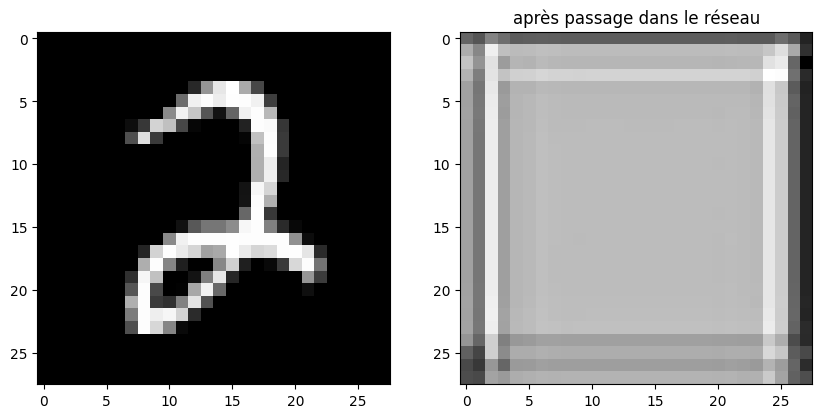

In [59]:
data_iter = iter(dataloader)
x, y = next(data_iter)
print(x.shape) 

unet = SimpleUNet()

t = torch.randint(0, 1000, (batch_size,)).float()  

# Test du modèle
x_u = unet(x, t)
fig, axe = plt.subplots(1, 2, figsize=(10, 5))
axe[0].imshow(x[0, 0].numpy(), cmap="gray")
axe[1].set_title("après passage dans le réseau") # par Unet
axe[1].imshow(x_u[0, 0].detach().numpy(), cmap="gray")

Générateur

Entraînement

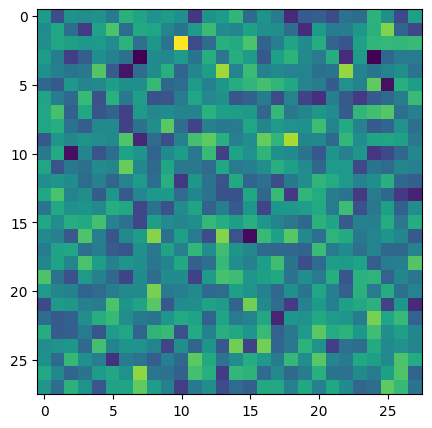

In [68]:
T = 1000
beta = torch.linspace(10*1e-4, 0.02, steps=T) # choix inspiré par de l'article de Ho et al. , c'est un HYPERPARAMETRE
alpha = torch.cumprod(1-beta, dim=0) # c'est alpha_bar de l'article de Ho et al.


def generate(nb_samples=1):
    # methode pour générer
    for _ in range(nb_samples):
        e_dist = torch.distributions.normal.Normal(0, 1) # N(0,1)
        X = e_dist.sample([input_size])
        
        for t in reversed(range(T)): # generate est une inversion
            t = torch.as_tensor([t])
            Zt = e_dist.sample([input_size])

            
            X_reshape = X.view(1, 1, 28, 28) # redimension
            in_tensor_ = X_reshape
            
            model_X = unet(in_tensor_, t.float())
            
            X = 1/((1-beta[t]).sqrt()) * (X - (beta[t]/((1-alpha[t]).sqrt()))*model_X.view(-1)) + beta[t]*Zt

        img = X.detach().numpy().reshape(28,28) # detach() = no gradient
        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.savefig("generate_from_mnist.png")
        plt.show()
generate()

In [64]:
nb_epochs = 1
criterion = nn.MSELoss() # loss function pour les bruits
unet = SimpleUNet()
model = unet

for epoch in range(nb_epochs):
    for X0, _ in tqdm(dataloader, desc=f"Epoch {epoch}/{nb_epochs}"):

        X0 = torch.flatten(X0.squeeze(), 1, 2) # -> [batchsize, 784]
        
        e_dist = torch.distributions.normal.Normal(0, 1) # N(0,1)
        e = e_dist.sample([batch_size, input_size])
        t = torch.randint(1, T, size=[batch_size, 1])
        
        Xt = alpha[t].sqrt() * X0 + (1-alpha[t]).sqrt() * e
        #in_tensor = torch.concat([Xt, t], dim=1).view(batch_size, 785, 1, 1)

        #print("Xt shape:", Xt.shape)
        #print("t shape:", t.shape)
        #print("in_tensor shape:", in_tensor.shape)
        #print("e shape:", e.shape)

        #print("in_tensor shape après reshaping:", in_tensor.shape)
        X_reshape = Xt.view(batch_size, 1, 28, 28)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        e_theta = model(X_reshape, t.float()) # 
        loss = criterion(e, e_theta.view(batch_size, -1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    #generate(1) # pour viz de l'évolution de la génération
    if epoch == nb_epochs-1: # test
        generate(1)    


Epoch 0/1:   0%|          | 0/468 [00:00<?, ?it/s]

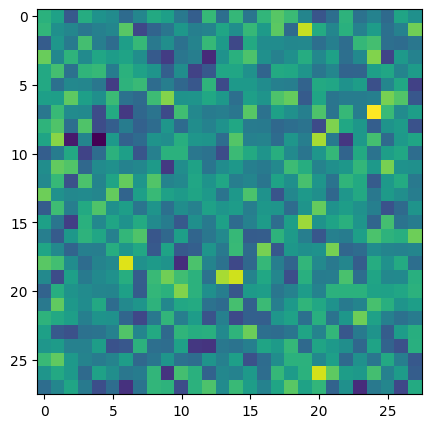

<Figure size 640x480 with 0 Axes>

In [67]:
generate(1) # pour viz de l'évolution de la génération
plt.savefig("resultat.png")

Sur le dataset CIFAR

In [27]:
TRANSFORMS2 = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # Normalisation
])
chemin = "./cifar-10-batches-py"
dataset = torchvision.datasets.CIFAR10(root=chemin, train=False, transform=TRANSFORMS2, download=False)

batch_size = 128
input_size = 32*32 #for CIFAR10

dataloader_cifar = DataLoader(torch.vision, batch_size=batch_size, shuffle=True, drop_last=F)

RuntimeError: Dataset not found or corrupted. You can use download=True to download it